# Notebook 11
 Final report ready figures

## Purpose:
 - Load final model results
 - Build compact comparison tables
 - Generate small, report-ready figures
 - Keep plotting consistent with src.utils.plotting

In [127]:
from pathlib import Path
import sys

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
PROJECT_ROOT = Path.cwd().resolve().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))


from src.utils.plotting import (
    STYLE,
    get_model_color,
    plot_equity_curve,
    plot_drawdown,
    plot_multi_series,
    plot_metric_bar,
    plot_grouped_metric_bars,
)

In [128]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

NOTEBOOK_NAME = "notebook11"

REPORTS_DIR = PROJECT_ROOT / "reports"
TABLES_DIR = REPORTS_DIR / "tables" / NOTEBOOK_NAME
FIGURES_DIR = REPORTS_DIR / "figures" / NOTEBOOK_NAME
EXPORTS_DIR = REPORTS_DIR / "exports"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
EXPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Tables dir :", TABLES_DIR)
print("Figures dir:", FIGURES_DIR)
print("Exports dir:", EXPORTS_DIR)

Project root: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml
Tables dir : c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook11
Figures dir: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\figures\notebook11
Exports dir: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\exports


In [129]:

STYLE.figsize = (7.2, 4.2)
STYLE.dpi = 300
STYLE.title_size = 12
STYLE.label_size = 10
STYLE.tick_size = 9
STYLE.legend_size = 9
STYLE.linewidth = 2.0
STYLE.grid_alpha = 0.35
STYLE.marker_size = 24

print(STYLE)

PlotStyleConfig(figsize=(7.2, 4.2), dpi=300, title_size=12, label_size=10, tick_size=9, legend_size=9, linewidth=2.0, grid_alpha=0.35, grid_linewidth=0.6, grid_linestyle='--', scatter_alpha=0.65, hist_alpha=0.85, marker_size=24, use_tight_layout=True)


In [130]:
import matplotlib.colors as mcolors

def adjust_color_brightness(color: str, factor: float = 1.0) -> str:
    """
    factor > 1.0 makes the color lighter
    factor < 1.0 makes the color darker
    """
    rgb = np.array(mcolors.to_rgb(color))
    if factor >= 1.0:
        adjusted = rgb + (1 - rgb) * (factor - 1.0)
    else:
        adjusted = rgb * factor
    adjusted = np.clip(adjusted, 0, 1)
    return mcolors.to_hex(adjusted)


def get_model_feature_color(family: str, feature_set: str) -> str:
    base = get_model_color(family)

    if feature_set == "Daily":
        return adjust_color_brightness(base, 1.16)   # lighter
    elif feature_set == "Daily+OHLCV":
        return adjust_color_brightness(base, 0.84)   # darker
    else:
        return base

In [131]:
RESULTS_ROOT = PROJECT_ROOT / "experiments" / "results"

MODEL_SPECS = [
    {
        "model": "Baseline",
        "short_label": "Baseline",
        "family": "baseline",
        "feature_set": "Baseline",
        "result_dir_candidates": [
            RESULTS_ROOT / "exp01_baseline_monthly",
            RESULTS_ROOT / "exp01_baseline",
        ],
    },
    {
        "model": "Ridge daily",
        "short_label": "Ridge-Daily",
        "family": "ridge",
        "feature_set": "Daily",
        "result_dir_candidates": [
            RESULTS_ROOT / "exp02_linear_ridge_daily",
        ],
    },
    {
        "model": "Ridge daily_ohlcv",
        "short_label": "Ridge-OHLCV",
        "family": "ridge",
        "feature_set": "Daily+OHLCV",
        "result_dir_candidates": [
            RESULTS_ROOT / "exp02_linear_ridge_daily_ohlcv",
        ],
    },
    {
        "model": "RF daily",
        "short_label": "RF-Daily",
        "family": "random_forest",
        "feature_set": "Daily",
        "result_dir_candidates": [
            RESULTS_ROOT / "exp04_random_forest_rolling_daily",
        ],
    },
    {
        "model": "RF daily_ohlcv",
        "short_label": "RF-OHLCV",
        "family": "random_forest",
        "feature_set": "Daily+OHLCV",
        "result_dir_candidates": [
            RESULTS_ROOT / "exp04_random_forest_rolling_daily_ohlcv",
        ],
    },
    {
        "model": "XGBoost daily",
        "short_label": "XGB-Daily",
        "family": "xgboost",
        "feature_set": "Daily",
        "result_dir_candidates": [
            RESULTS_ROOT / "exp03_xgboost_rolling_daily",
        ],
    },
    {
        "model": "XGBoost daily_ohlcv",
        "short_label": "XGB-OHLCV",
        "family": "xgboost",
        "feature_set": "Daily+OHLCV",
        "result_dir_candidates": [
            RESULTS_ROOT / "exp03_xgboost_rolling_daily_ohlcv",
        ],
    },
    {
        "model": "MLP daily",
        "short_label": "MLP-Daily",
        "family": "mlp",
        "feature_set": "Daily",
        "result_dir_candidates": [
            RESULTS_ROOT / "exp05_nn_mlp_daily",
        ],
    },
    {
        "model": "MLP daily_ohlcv",
        "short_label": "MLP-OHLCV",
        "family": "mlp",
        "feature_set": "Daily+OHLCV",
        "result_dir_candidates": [
            RESULTS_ROOT / "exp05_nn_mlp_daily_ohlcv",
        ],
    },
    {
        "model": "LSTM",
        "short_label": "LSTM-Daily",
        "family": "lstm",
        "feature_set": "Daily",
        "result_dir_candidates": [
            RESULTS_ROOT / "exp06_lstm_daily",
        ],
    },
]

COST_KEY = "cost_10bps"   

In [152]:
def first_existing_path(paths):
    for path in paths:
        if path.exists():
            return path
    return None


def load_json_if_exists(path):
    if path is None or not path.exists():
        return None
    with open(path, "r") as f:
        return json.load(f)


def pick_first(d, keys, default=np.nan):
    if d is None:
        return default
    for key in keys:
        if key in d and pd.notna(d[key]):
            return d[key]
    return default


def load_equity_series(path):
    if path is None or not path.exists():
        return None

    df = pd.read_csv(path, index_col=0)
    if df.shape[1] == 1:
        s = df.iloc[:, 0].copy()
    else:
        s = df.squeeze("columns")
    s.index = pd.to_datetime(s.index)
    return s.sort_index()


def load_selection_summary(result_dir):
    out = {
        "best_stocks_avg_return": np.nan,
        "market_avg_return": np.nan,
        "worst_stocks_avg_return": np.nan,
        "best_stocks_advantage_over_market_avg": np.nan,
        "best_minus_worst": np.nan,
        "pct_months_best_above_market": np.nan,
        "best_stock_overlap_rate": np.nan,
        "worst_stock_overlap_rate": np.nan,
    }

    spreads_path = result_dir / "selection_diagnostics" / "selection_spreads_summary.csv"
    overlap_path = result_dir / "selection_diagnostics" / "top_bottom_overlap_summary.csv"

    if spreads_path.exists():
        row = pd.read_csv(spreads_path).iloc[0].to_dict()

        out["best_stocks_avg_return"] = pick_first(
            row, ["mean_top_avg_return", "top_avg_return_mean"]
        )
        out["market_avg_return"] = pick_first(
            row, ["mean_all_avg_return", "all_avg_return_mean"]
        )
        out["worst_stocks_avg_return"] = pick_first(
            row, ["mean_bottom_avg_return", "bottom_avg_return_mean"]
        )
        out["best_stocks_advantage_over_market_avg"] = pick_first(
            row, ["mean_top_minus_all", "top_minus_all_mean"]
        )
        out["best_minus_worst"] = pick_first(
            row, ["mean_top_minus_bottom", "top_minus_bottom_mean"]
        )

        pct = pick_first(
            row,
            ["pct_months_top_gt_all", "pct_top_gt_all", "top_beats_market_pct"],
            default=np.nan,
        )
        if pd.notna(pct) and pct <= 1:
            pct *= 100
        out["pct_months_best_above_market"] = pct

    if overlap_path.exists():
        row = pd.read_csv(overlap_path).iloc[0].to_dict()

        top_overlap = pick_first(
            row, ["mean_top_overlap_rate", "top_overlap_rate_mean"]
        )
        bottom_overlap = pick_first(
            row, ["mean_bottom_overlap_rate", "bottom_overlap_rate_mean"]
        )

        if pd.notna(top_overlap) and top_overlap <= 1:
            top_overlap *= 100
        if pd.notna(bottom_overlap) and bottom_overlap <= 1:
            bottom_overlap *= 100

        out["best_stock_overlap_rate"] = top_overlap
        out["worst_stock_overlap_rate"] = bottom_overlap

    return out


def load_split_metrics(result_dir, split="test", use_costs=True, cost_key="cost_10bps"):
    if split == "train":
        base_path_candidates = [
            result_dir / "metrics_train.json",
        ]
        cost_path_candidates = [
            result_dir / "metrics_train_with_costs.json",
        ]
    else:
        base_path_candidates = [
            result_dir / "metrics_test_2025.json",
            result_dir / "metrics_test.json",
        ]
        cost_path_candidates = [
            result_dir / "metrics_test_2025_with_costs.json",
            result_dir / "metrics_test_with_costs.json",
        ]

    base_path = first_existing_path(base_path_candidates)
    cost_path = first_existing_path(cost_path_candidates)

    base_metrics = load_json_if_exists(base_path) or {}
    cost_metrics = load_json_if_exists(cost_path) or {}

    if use_costs and cost_key in cost_metrics:
        return cost_metrics[cost_key]

    return base_metrics


def load_prediction_metrics(result_dir):
    pred_metrics = load_json_if_exists(result_dir / "prediction_metrics.json") or {}

    train_block = (
        pred_metrics.get("train")
        or pred_metrics.get("train_static_fit")
        or {}
    )

    test_block = (
        pred_metrics.get("test_2025")
        or pred_metrics.get("test_2025_rolling_fit")
        or {}
    )

    train_reg = train_block.get("regression", {})
    train_rank = train_block.get("ranking", {})
    test_reg = test_block.get("regression", {})
    test_rank = test_block.get("ranking", {})

    return train_reg, train_rank, test_reg, test_rank


def build_model_record(spec, cost_key="cost_10bps"):
    result_dir = first_existing_path(spec["result_dir_candidates"])
    if result_dir is None:
        return None

    train_metrics = load_split_metrics(result_dir, split="train", use_costs=True, cost_key=cost_key)
    test_metrics = load_split_metrics(result_dir, split="test", use_costs=True, cost_key=cost_key)

    train_reg, train_rank, test_reg, test_rank = load_prediction_metrics(result_dir)
    selection = load_selection_summary(result_dir)

    record = {
        "model": spec["model"],
        "short_label": spec["short_label"],
        "family": spec["family"],
        "feature_set": spec["feature_set"],
        "result_dir": str(result_dir),

        # strategy metrics: train
        "train_cumulative_return": pick_first(train_metrics, ["cumulative_return"]),
        "train_annualized_return": pick_first(train_metrics, ["annualized_return"]),
        "train_annualized_volatility": pick_first(train_metrics, ["annualized_volatility"]),
        "train_sharpe_ratio": pick_first(train_metrics, ["sharpe_ratio"]),
        "train_max_drawdown": pick_first(train_metrics, ["max_drawdown"]),
        "train_turnover": pick_first(train_metrics, ["avg_turnover", "average_turnover", "turnover"]),

        # strategy metrics: test
        "test_cumulative_return": pick_first(test_metrics, ["cumulative_return"]),
        "test_annualized_return": pick_first(test_metrics, ["annualized_return"]),
        "test_annualized_volatility": pick_first(test_metrics, ["annualized_volatility"]),
        "test_sharpe_ratio": pick_first(test_metrics, ["sharpe_ratio"]),
        "test_max_drawdown": pick_first(test_metrics, ["max_drawdown"]),
        "test_turnover": pick_first(test_metrics, ["avg_turnover", "average_turnover", "turnover"]),

        # prediction metrics: train
        "train_rmse": pick_first(train_reg, ["RMSE"]),
        "train_r2": pick_first(train_reg, ["R2"]),
        "train_directional_accuracy": pick_first(train_reg, ["Directional_Accuracy"]),
        "train_spearman": pick_first(train_rank, ["SpearmanRankCorr_mean"]),
        "train_topk_hit_rate": pick_first(train_rank, ["TopKHitRate_mean"]),

        # prediction metrics: test
        "test_rmse": pick_first(test_reg, ["RMSE"]),
        "test_r2": pick_first(test_reg, ["R2"]),
        "test_directional_accuracy": pick_first(test_reg, ["Directional_Accuracy"]),
        "test_spearman": pick_first(test_rank, ["SpearmanRankCorr_mean"]),
        "test_topk_hit_rate": pick_first(test_rank, ["TopKHitRate_mean"]),
    }

    record.update(selection)

    return record

In [153]:
records = []
missing_models = []

for spec in MODEL_SPECS:
    record = build_model_record(spec, cost_key=COST_KEY)
    if record is None:
        missing_models.append(spec["model"])
    else:
        records.append(record)

results_df = pd.DataFrame(records)

print("Loaded models:", list(results_df["short_label"]))
print("Missing models:", missing_models if missing_models else "None")

display(results_df)

Loaded models: ['Baseline', 'Ridge-Daily', 'Ridge-OHLCV', 'RF-Daily', 'RF-OHLCV', 'XGB-Daily', 'XGB-OHLCV', 'MLP-Daily', 'MLP-OHLCV', 'LSTM-Daily']
Missing models: None


,model,short_label,family,feature_set,result_dir,train_cumulative_return,train_annualized_return,train_annualized_volatility,train_sharpe_ratio,train_max_drawdown,...,test_spearman,test_topk_hit_rate,best_stocks_avg_return,market_avg_return,worst_stocks_avg_return,best_stocks_advantage_over_market_avg,best_minus_worst,pct_months_best_above_market,best_stock_overlap_rate,worst_stock_overlap_rate
0,Baseline,Baseline,baseline,Baseline,c:\Users\amila\OneDrive\UH\DSP\Git\stability-a...,1.535721,0.097514,0.130693,0.781201,-0.255633,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Ridge daily,Ridge-Daily,ridge,Daily,c:\Users\amila\OneDrive\UH\DSP\Git\stability-a...,1.930953,0.113527,0.211228,0.617166,-0.361414,...,0.042863,0.301435,0.024695,0.014733,0.011326,0.009962,0.013369,54.545455,29.797980,19.191919
2,Ridge daily_ohlcv,Ridge-OHLCV,ridge,Daily+OHLCV,c:\Users\amila\OneDrive\UH\DSP\Git\stability-a...,2.345900,0.128369,0.214509,0.673107,-0.385147,...,0.048692,0.272727,0.020166,0.014733,0.013413,0.005434,0.006753,54.545455,27.777778,18.181818
3,RF daily,RF-Daily,random_forest,Daily,c:\Users\amila\OneDrive\UH\DSP\Git\stability-a...,5.044069,0.197107,0.203281,0.987017,-0.262334,...,0.051451,0.363636,0.034481,0.014733,0.011795,0.019748,0.022686,54.545455,36.868687,18.686869
4,RF daily_ohlcv,RF-OHLCV,random_forest,Daily+OHLCV,c:\Users\amila\OneDrive\UH\DSP\Git\stability-a...,5.812510,0.211520,0.201025,1.056305,-0.266061,...,0.081832,0.373206,0.034969,0.014733,0.012754,0.020237,0.022216,72.727273,36.868687,20.707071
5,XGBoost daily,XGB-Daily,xgboost,Daily,c:\Users\amila\OneDrive\UH\DSP\Git\stability-a...,58.712374,0.505242,0.200163,2.169340,-0.193538,...,0.055333,0.320574,0.029351,0.014733,0.010598,0.014618,0.018753,72.727273,31.818182,19.696970
6,XGBoost daily_ohlcv,XGB-OHLCV,xgboost,Daily+OHLCV,c:\Users\amila\OneDrive\UH\DSP\Git\stability-a...,88.014794,0.566557,0.195582,2.427002,-0.171709,...,0.037959,0.296651,0.027553,0.014733,0.005482,0.012820,0.022071,72.727273,29.797980,22.222222
7,MLP daily,MLP-Daily,mlp,Daily,c:\Users\amila\OneDrive\UH\DSP\Git\stability-a...,4.248527,0.180331,0.197849,0.936064,-0.230362,...,0.081893,0.306220,0.029427,0.014733,0.013305,0.014695,0.016123,63.636364,30.303030,18.686869
8,MLP daily_ohlcv,MLP-OHLCV,mlp,Daily+OHLCV,c:\Users\amila\OneDrive\UH\DSP\Git\stability-a...,4.209686,0.179454,0.187584,0.973123,-0.224028,...,-0.042016,0.248804,0.015735,0.014733,0.018756,0.001002,-0.003021,54.545455,24.747475,16.161616
9,LSTM,LSTM-Daily,lstm,Daily,c:\Users\amila\OneDrive\UH\DSP\Git\stability-a...,0.901586,0.066379,0.146048,0.513774,-0.238760,...,0.021652,0.196704,0.016693,0.014569,0.012945,0.002124,0.003748,54.545455,19.191919,20.202020


In [154]:
REPORT_ORDER = [
    "Baseline",
    "Ridge-Daily", "Ridge-OHLCV",
    "RF-Daily", "RF-OHLCV",
    "XGB-Daily", "XGB-OHLCV",
    "MLP-Daily", "MLP-OHLCV",
    "LSTM-Daily",
]

available_order = [m for m in REPORT_ORDER if m in results_df["short_label"].tolist()]
results_df["short_label"] = pd.Categorical(results_df["short_label"], categories=available_order, ordered=True)
results_df = results_df.sort_values("short_label").reset_index(drop=True)

color_map = {
    row["short_label"]: get_model_color(row["family"])
    for _, row in results_df.iterrows()
}

results_df.to_csv(TABLES_DIR / "model_results_master.csv", index=False)
display(results_df[[
    "short_label", "feature_set",
    "train_sharpe_ratio", "test_sharpe_ratio",
    "test_cumulative_return",
    "test_spearman",
    "test_topk_hit_rate",
    "best_stocks_advantage_over_market_avg",
    "best_minus_worst",
    "pct_months_best_above_market"
]])

,short_label,feature_set,train_sharpe_ratio,test_sharpe_ratio,test_cumulative_return,test_spearman,test_topk_hit_rate,best_stocks_advantage_over_market_avg,best_minus_worst,pct_months_best_above_market
0,Baseline,Baseline,0.781201,2.547364,0.378629,NaN,NaN,NaN,NaN,NaN
1,Ridge-Daily,Daily,0.617166,1.312170,0.212008,0.042863,0.301435,0.009962,0.013369,54.545455
2,Ridge-OHLCV,Daily+OHLCV,0.673107,0.968834,0.155003,0.048692,0.272727,0.005434,0.006753,54.545455
3,RF-Daily,Daily,0.987017,2.202587,0.352515,0.051451,0.363636,0.019748,0.022686,54.545455
4,RF-OHLCV,Daily+OHLCV,1.056305,2.298426,0.378970,0.081832,0.373206,0.020237,0.022216,72.727273
5,XGB-Daily,Daily,2.169340,2.048309,0.299978,0.055333,0.320574,0.014618,0.018753,72.727273
6,XGB-OHLCV,Daily+OHLCV,2.427002,2.041950,0.271899,0.037959,0.296651,0.012820,0.022071,72.727273
7,MLP-Daily,Daily,0.936064,1.928357,0.284715,0.081893,0.306220,0.014695,0.016123,63.636364
8,MLP-OHLCV,Daily+OHLCV,0.973123,0.966599,0.134222,-0.042016,0.248804,0.001002,-0.003021,54.545455
9,LSTM-Daily,Daily,0.513774,1.741049,0.160830,0.021652,0.196704,0.002124,0.003748,54.545455


In [156]:
# strategy_table = results_df[[
#     "short_label",
#     "feature_set",
#     "train_cumulative_return",
#     "train_sharpe_ratio",
#     "test_cumulative_return",
#     "test_sharpe_ratio",
#     "test_max_drawdown",
# ]].copy()
strategy_table = results_df[[
    "short_label",
    "train_cumulative_return",
    "train_sharpe_ratio",
    "train_turnover",
    "test_cumulative_return",
    "test_sharpe_ratio",
    "test_max_drawdown",
    "test_turnover",
]].copy()

strategy_table = strategy_table.rename(columns={
    "short_label": "Model",
    "train_cumulative_return": "Train Cumulative Return",
    "train_sharpe_ratio": "Train Sharpe Ratio",
    "train_turnover": "Train Turnover",
    "test_cumulative_return": "Test Cumulative Return",
    "test_sharpe_ratio": "Test Sharpe Ratio",
    "test_max_drawdown": "Test Max Drawdown",
    "test_turnover": "Test Turnover",
})

strategy_table = strategy_table.round(3)

strategy_table.to_csv(TABLES_DIR / "table_6_portfolio_metrics.csv", index=False)

display(strategy_table)
print("Saved:", TABLES_DIR / "table_6_portfolio_metrics.csv")

ranking_table = results_df[[
    "short_label",
    "train_spearman",
    "test_spearman",
    "train_topk_hit_rate",
    "test_topk_hit_rate",
]].copy()

selection_table = results_df[[
    "short_label",
    "best_stocks_avg_return",
    "market_avg_return",
    "worst_stocks_avg_return",
    "best_stocks_advantage_over_market_avg",
    "best_minus_worst",
    "pct_months_best_above_market",
    "best_stock_overlap_rate",
    "worst_stock_overlap_rate",
]].copy()

strategy_table.to_csv(TABLES_DIR / "strategy_table.csv", index=False)
ranking_table.to_csv(TABLES_DIR / "ranking_table.csv", index=False)
selection_table.to_csv(TABLES_DIR / "selection_table.csv", index=False)

display(strategy_table)
display(ranking_table)
display(selection_table)

,Model,Train Cumulative Return,Train Sharpe Ratio,Train Turnover,Test Cumulative Return,Test Sharpe Ratio,Test Max Drawdown,Test Turnover
0,Baseline,1.536,0.781,0.206,0.379,2.547,-0.069,0.137
1,Ridge-Daily,1.931,0.617,0.396,0.212,1.312,-0.062,0.426
2,Ridge-OHLCV,2.346,0.673,0.424,0.155,0.969,-0.073,0.455
3,RF-Daily,5.044,0.987,0.381,0.353,2.203,-0.038,0.335
4,RF-OHLCV,5.813,1.056,0.388,0.379,2.298,-0.046,0.301
5,XGB-Daily,58.712,2.169,0.647,0.300,2.048,-0.046,0.488
6,XGB-OHLCV,88.015,2.427,0.628,0.272,2.042,-0.051,0.483
7,MLP-Daily,4.249,0.936,0.533,0.285,1.928,-0.044,0.450
8,MLP-OHLCV,4.210,0.973,0.616,0.134,0.967,-0.081,0.550
9,LSTM-Daily,0.902,0.514,0.716,0.161,1.741,-0.040,0.673


Saved: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook11\table_6_portfolio_metrics.csv


,Model,Train Cumulative Return,Train Sharpe Ratio,Train Turnover,Test Cumulative Return,Test Sharpe Ratio,Test Max Drawdown,Test Turnover
0,Baseline,1.536,0.781,0.206,0.379,2.547,-0.069,0.137
1,Ridge-Daily,1.931,0.617,0.396,0.212,1.312,-0.062,0.426
2,Ridge-OHLCV,2.346,0.673,0.424,0.155,0.969,-0.073,0.455
3,RF-Daily,5.044,0.987,0.381,0.353,2.203,-0.038,0.335
4,RF-OHLCV,5.813,1.056,0.388,0.379,2.298,-0.046,0.301
5,XGB-Daily,58.712,2.169,0.647,0.300,2.048,-0.046,0.488
6,XGB-OHLCV,88.015,2.427,0.628,0.272,2.042,-0.051,0.483
7,MLP-Daily,4.249,0.936,0.533,0.285,1.928,-0.044,0.450
8,MLP-OHLCV,4.210,0.973,0.616,0.134,0.967,-0.081,0.550
9,LSTM-Daily,0.902,0.514,0.716,0.161,1.741,-0.040,0.673


,short_label,train_spearman,test_spearman,train_topk_hit_rate,test_topk_hit_rate
0,Baseline,NaN,NaN,NaN,NaN
1,Ridge-Daily,0.019285,0.042863,0.277330,0.301435
2,Ridge-OHLCV,0.027545,0.048692,0.280565,0.272727
3,RF-Daily,0.075922,0.051451,0.301376,0.363636
4,RF-OHLCV,0.092637,0.081832,0.298715,0.373206
5,XGB-Daily,0.278567,0.055333,0.378102,0.320574
6,XGB-OHLCV,0.317149,0.037959,0.387226,0.296651
7,MLP-Daily,0.075078,0.081893,0.283921,0.306220
8,MLP-OHLCV,0.082864,-0.042016,0.270591,0.248804
9,LSTM-Daily,-0.001254,0.021652,0.205130,0.196704


,short_label,best_stocks_avg_return,market_avg_return,worst_stocks_avg_return,best_stocks_advantage_over_market_avg,best_minus_worst,pct_months_best_above_market,best_stock_overlap_rate,worst_stock_overlap_rate
0,Baseline,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Ridge-Daily,0.024695,0.014733,0.011326,0.009962,0.013369,54.545455,29.797980,19.191919
2,Ridge-OHLCV,0.020166,0.014733,0.013413,0.005434,0.006753,54.545455,27.777778,18.181818
3,RF-Daily,0.034481,0.014733,0.011795,0.019748,0.022686,54.545455,36.868687,18.686869
4,RF-OHLCV,0.034969,0.014733,0.012754,0.020237,0.022216,72.727273,36.868687,20.707071
5,XGB-Daily,0.029351,0.014733,0.010598,0.014618,0.018753,72.727273,31.818182,19.696970
6,XGB-OHLCV,0.027553,0.014733,0.005482,0.012820,0.022071,72.727273,29.797980,22.222222
7,MLP-Daily,0.029427,0.014733,0.013305,0.014695,0.016123,63.636364,30.303030,18.686869
8,MLP-OHLCV,0.015735,0.014733,0.018756,0.001002,-0.003021,54.545455,24.747475,16.161616
9,LSTM-Daily,0.016693,0.014569,0.012945,0.002124,0.003748,54.545455,19.191919,20.202020


In [136]:
color_map = {
    row["short_label"]: get_model_feature_color(row["family"], row["feature_set"])
    for _, row in results_df.iterrows()
}

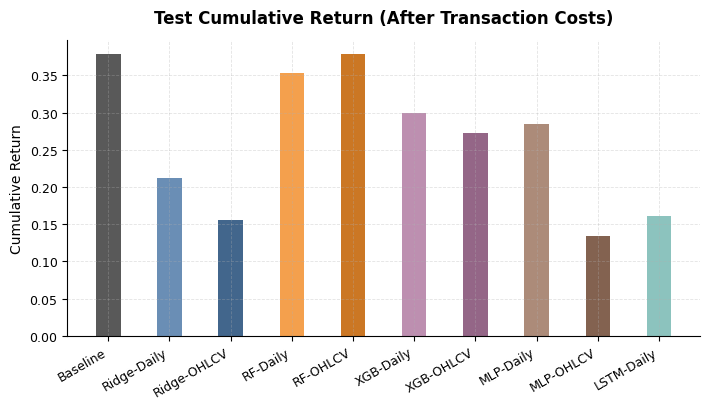

Saved: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\figures\notebook11\fig11_01_test_cumulative_return.png


In [137]:
fig_df = results_df.dropna(subset=["test_cumulative_return"]).copy()
values = fig_df.set_index("short_label")["test_cumulative_return"]

plot_metric_bar(
    values=values,
    title="Test Cumulative Return (After Transaction Costs)",
    ylabel="Cumulative Return",
    save_path=str(FIGURES_DIR / "fig11_01_test_cumulative_return.png"),
    color_map=color_map,
    show=True,
)

print("Saved:", FIGURES_DIR / "fig11_01_test_cumulative_return.png")

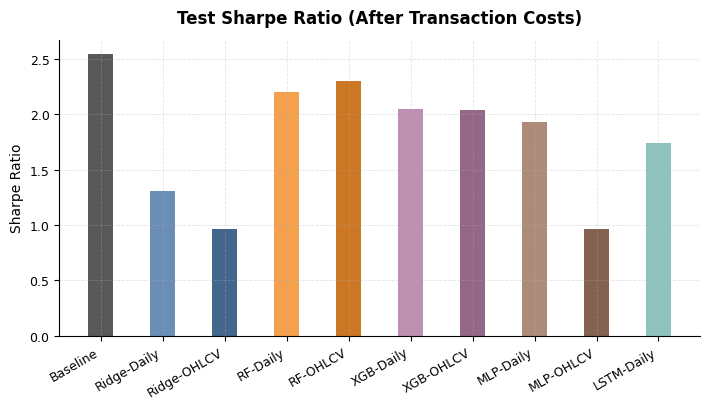

Saved: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\figures\notebook11\fig11_02_test_sharpe_ratio.png


In [138]:
fig_df = results_df.dropna(subset=["test_sharpe_ratio"]).copy()
values = fig_df.set_index("short_label")["test_sharpe_ratio"]

plot_metric_bar(
    values=values,
    title="Test Sharpe Ratio (After Transaction Costs)",
    ylabel="Sharpe Ratio",
    save_path=str(FIGURES_DIR / "fig11_02_test_sharpe_ratio.png"),
    color_map=color_map,
    show=True,
)

print("Saved:", FIGURES_DIR / "fig11_02_test_sharpe_ratio.png")

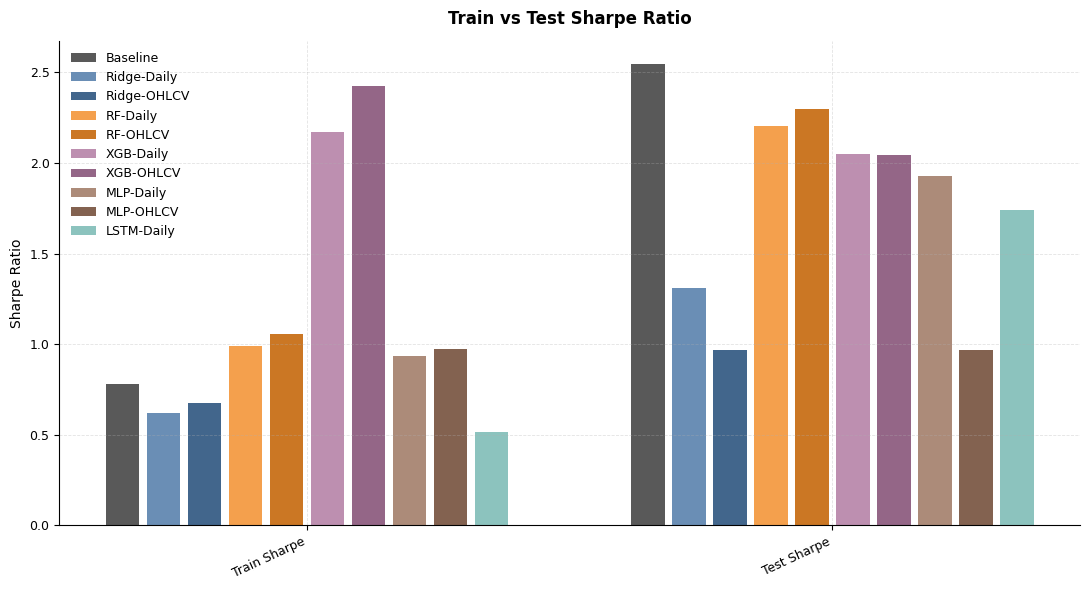

Saved: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\figures\notebook11\fig11_03_train_vs_test_sharpe.png


In [139]:
metric_df = results_df.set_index("short_label")[[
    "train_sharpe_ratio",
    "test_sharpe_ratio"
]].T

metric_df.index = ["Train Sharpe", "Test Sharpe"]

plot_grouped_metric_bars(
    metric_df=metric_df,
    title="Train vs Test Sharpe Ratio",
    ylabel="Sharpe Ratio",
    save_path=str(FIGURES_DIR / "fig11_03_train_vs_test_sharpe.png"),
    color_map=color_map,
    show=True,
)

print("Saved:", FIGURES_DIR / "fig11_03_train_vs_test_sharpe.png")

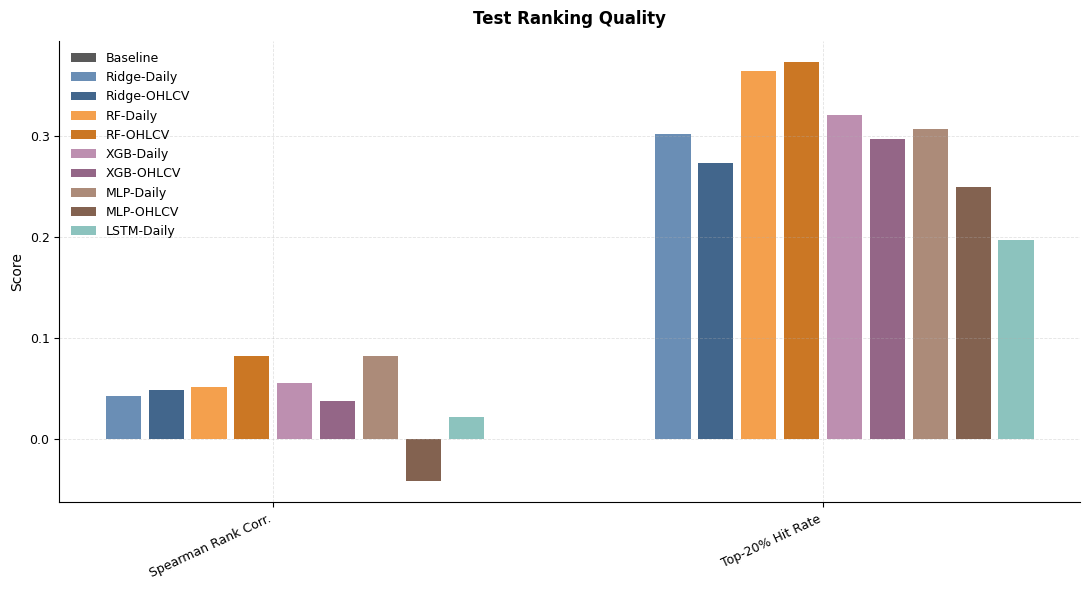

Saved: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\figures\notebook11\fig11_04_test_ranking_quality.png


In [140]:
metric_df = results_df.set_index("short_label")[[
    "test_spearman",
    "test_topk_hit_rate"
]].T

metric_df.index = ["Spearman Rank Corr.", "Top-20% Hit Rate"]

plot_grouped_metric_bars(
    metric_df=metric_df,
    title="Test Ranking Quality",
    ylabel="Score",
    save_path=str(FIGURES_DIR / "fig11_04_test_ranking_quality.png"),
    color_map=color_map,
    show=True,
)

print("Saved:", FIGURES_DIR / "fig11_04_test_ranking_quality.png")

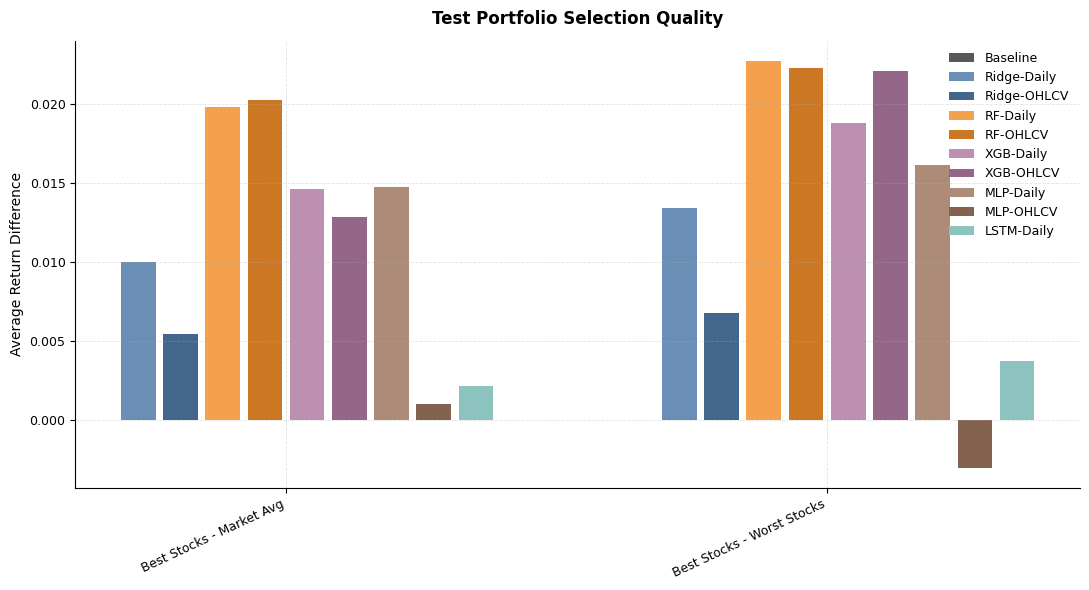

Saved: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\figures\notebook11\fig11_05_selection_quality.png


In [141]:
metric_df = results_df.set_index("short_label")[[
    "best_stocks_advantage_over_market_avg",
    "best_minus_worst"
]].T

metric_df.index = [
    "Best Stocks - Market Avg",
    "Best Stocks - Worst Stocks"
]

plot_grouped_metric_bars(
    metric_df=metric_df,
    title="Test Portfolio Selection Quality",
    ylabel="Average Return Difference",
    save_path=str(FIGURES_DIR / "fig11_05_selection_quality.png"),
    color_map=color_map,
    show=True,
)

print("Saved:", FIGURES_DIR / "fig11_05_selection_quality.png")

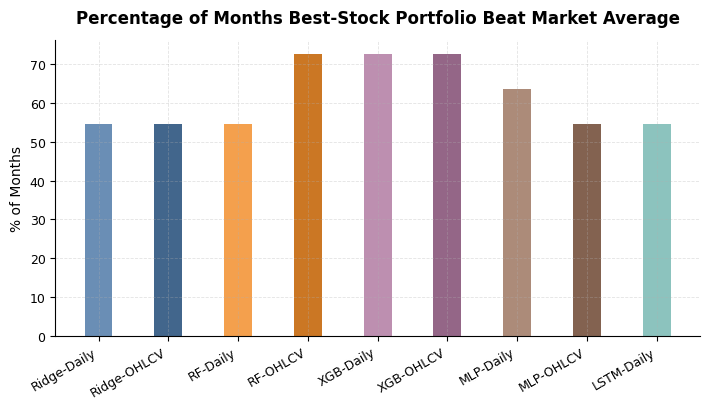

Saved: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\figures\notebook11\fig11_06_pct_months_best_above_market.png


In [142]:
fig_df = results_df.dropna(subset=["pct_months_best_above_market"]).copy()
values = fig_df.set_index("short_label")["pct_months_best_above_market"]

plot_metric_bar(
    values=values,
    title="Percentage of Months Best-Stock Portfolio Beat Market Average",
    ylabel="% of Months",
    save_path=str(FIGURES_DIR / "fig11_06_pct_months_best_above_market.png"),
    color_map=color_map,
    show=True,
)

print("Saved:", FIGURES_DIR / "fig11_06_pct_months_best_above_market.png")

Equity curve models: ['Baseline', 'RF-Daily', 'RF-OHLCV', 'XGB-Daily']


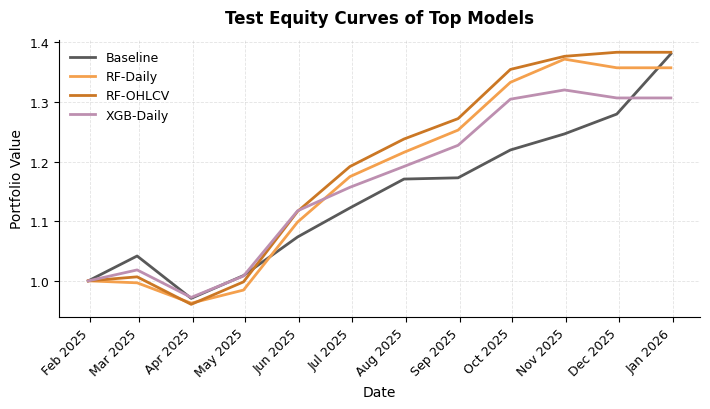

Saved: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\figures\notebook11\fig11_07_test_equity_curves_top_models.png


In [143]:

top_models = (
    results_df.dropna(subset=["test_sharpe_ratio"])
    .sort_values("test_sharpe_ratio", ascending=False)
    .head(4)
    ["short_label"]
    .tolist()
)

series_map = {}
equity_color_map = {}

for _, row in results_df.iterrows():
    if row["short_label"] not in top_models:
        continue

    result_dir = Path(row["result_dir"])
    equity_path = result_dir / "equity_test_2025.csv"
    s = load_equity_series(equity_path)

    if s is not None:
        series_map[row["short_label"]] = s
        equity_color_map[row["short_label"]] = color_map[row["short_label"]]

print("Equity curve models:", list(series_map.keys()))

plot_multi_series(
    series_map=series_map,
    title="Test Equity Curves of Top Models",
    ylabel="Portfolio Value",
    save_path=str(FIGURES_DIR / "fig11_07_test_equity_curves_top_models.png"),
    color_map=equity_color_map,
    show=True,
)

print("Saved:", FIGURES_DIR / "fig11_07_test_equity_curves_top_models.png")

Best model on test Sharpe: Baseline


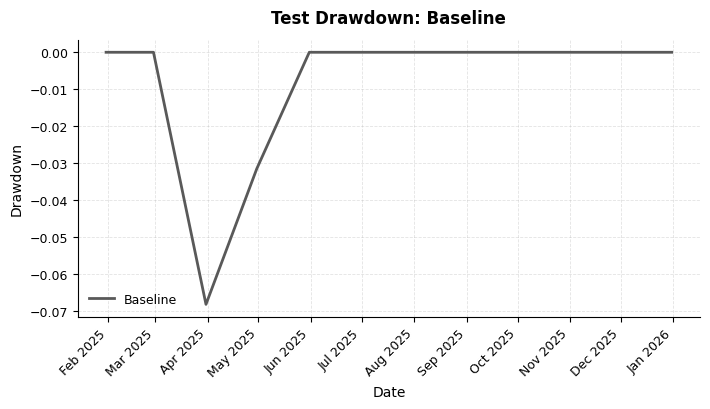

Saved: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\figures\notebook11\fig11_08_best_model_drawdown.png


In [144]:
best_row = (
    results_df.dropna(subset=["test_sharpe_ratio"])
    .sort_values("test_sharpe_ratio", ascending=False)
    .iloc[0]
)

best_model_label = best_row["short_label"]
best_model_color = color_map[best_model_label]
best_equity_path = Path(best_row["result_dir"]) / "equity_test_2025.csv"
best_equity = load_equity_series(best_equity_path)

print("Best model on test Sharpe:", best_model_label)

plot_drawdown(
    equity_curve=best_equity,
    title=f"Test Drawdown: {best_model_label}",
    label=best_model_label,
    color=best_model_color,
    save_path=str(FIGURES_DIR / "fig11_08_best_model_drawdown.png"),
    show=True,
)

print("Saved:", FIGURES_DIR / "fig11_08_best_model_drawdown.png")

In [145]:
excel_path = EXPORTS_DIR / "notebook11_report_ready_tables.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    results_df.to_excel(writer, sheet_name="master_results", index=False)
    strategy_table.to_excel(writer, sheet_name="strategy_table", index=False)
    ranking_table.to_excel(writer, sheet_name="ranking_table", index=False)
    selection_table.to_excel(writer, sheet_name="selection_table", index=False)

print("Saved:", excel_path)

ModuleNotFoundError: No module named 'openpyxl'

In [ ]:
print("=== Saved figures ===")
for path in sorted(FIGURES_DIR.glob("*.png")):
    print(path.name)

print("\n=== Saved tables ===")
for path in sorted(TABLES_DIR.glob("*")):
    print(path.name)

=== Saved figures ===
fig11_01_test_cumulative_return.png
fig11_02_test_sharpe_ratio.png
fig11_03_train_vs_test_sharpe.png
fig11_04_test_ranking_quality.png
fig11_05_selection_quality.png
fig11_06_pct_months_best_above_market.png
fig11_07_test_equity_curves_top_models.png
fig11_08_best_model_drawdown.png

=== Saved tables ===
model_results_master.csv
ranking_table.csv
selection_table.csv
strategy_table.csv


In [147]:
import json
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display

# Assumes these already exist in Notebook 11:
# - PROJECT_ROOT
# - TABLES_DIR
# - MODEL_SPECS
# - first_existing_path
# - load_json_if_exists

RESULTS_ROOT = PROJECT_ROOT / "experiments" / "results"


def extract_prediction_blocks(pred_metrics: dict, family: str):
    """
    Support both:
    - standard format: train / test_2025
    - rolling-tree format: train_static_fit / test_2025_rolling_fit
    """
    if family in ["random_forest", "xgboost"]:
        train_block = pred_metrics.get("train_static_fit", {})
        test_block = pred_metrics.get("test_2025_rolling_fit", {})
    else:
        train_block = pred_metrics.get("train", {})
        test_block = pred_metrics.get("test_2025", {})

    train_reg = train_block.get("regression", {})
    train_rank = train_block.get("ranking", {})
    test_reg = test_block.get("regression", {})
    test_rank = test_block.get("ranking", {})

    return train_reg, train_rank, test_reg, test_rank


rows = []

for spec in MODEL_SPECS:
    result_dir = first_existing_path(spec["result_dir_candidates"])
    if result_dir is None:
        continue

    pred_metrics_path = result_dir / "prediction_metrics.json"
    pred_metrics = load_json_if_exists(pred_metrics_path)

    if pred_metrics is None:
        print(f"Missing prediction metrics: {pred_metrics_path}")
        continue

    train_reg, train_rank, test_reg, test_rank = extract_prediction_blocks(
        pred_metrics,
        spec["family"]
    )

    rows.append({
        "Model": spec["short_label"],

        "Train MAE": train_reg.get("MAE", np.nan),
        "Train RMSE": train_reg.get("RMSE", np.nan),
        "Train R²": train_reg.get("R2", np.nan),
        "Train Dir. Acc.": train_reg.get("Directional_Accuracy", np.nan),
        "Train Spearman": train_rank.get("SpearmanRankCorr_mean", np.nan),
        "Train Top-20% Hit Rate": train_rank.get("TopKHitRate_mean", np.nan),

        "Test MAE": test_reg.get("MAE", np.nan),
        "Test RMSE": test_reg.get("RMSE", np.nan),
        "Test R²": test_reg.get("R2", np.nan),
        "Test Dir. Acc.": test_reg.get("Directional_Accuracy", np.nan),
        "Test Spearman": test_rank.get("SpearmanRankCorr_mean", np.nan),
        "Test Top-20% Hit Rate": test_rank.get("TopKHitRate_mean", np.nan),
    })

prediction_metrics_df = pd.DataFrame(rows)

# Respect report order if available
if "REPORT_ORDER" in globals():
    available_order = [m for m in REPORT_ORDER if m in prediction_metrics_df["Model"].tolist()]
    prediction_metrics_df["Model"] = pd.Categorical(
        prediction_metrics_df["Model"],
        categories=available_order,
        ordered=True
    )
    prediction_metrics_df = prediction_metrics_df.sort_values("Model").reset_index(drop=True)

prediction_metrics_df = prediction_metrics_df.round(4)

display(prediction_metrics_df)

Missing prediction metrics: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\experiments\results\exp01_baseline_monthly\prediction_metrics.json


,Model,Train MAE,Train RMSE,Train R²,Train Dir. Acc.,Train Spearman,Train Top-20% Hit Rate,Test MAE,Test RMSE,Test R²,Test Dir. Acc.,Test Spearman,Test Top-20% Hit Rate
0,Ridge-Daily,0.0591,0.0810,0.0175,0.5305,0.0193,0.2773,0.0545,0.0734,0.0176,0.5547,0.0429,0.3014
1,Ridge-OHLCV,0.0589,0.0806,0.0234,0.5361,0.0275,0.2806,0.0547,0.0739,0.0040,0.5615,0.0487,0.2727
2,RF-Daily,0.0583,0.0792,0.0592,0.5460,0.0759,0.3014,0.0548,0.0739,0.0042,0.5635,0.0515,0.3636
3,RF-OHLCV,0.0581,0.0789,0.0638,0.5470,0.0926,0.2987,0.0547,0.0738,0.0052,0.5654,0.0818,0.3732
4,XGB-Daily,0.0541,0.0713,0.2390,0.6050,0.2786,0.3781,0.0551,0.0740,0.0010,0.5361,0.0553,0.3206
5,XGB-OHLCV,0.0532,0.0698,0.2674,0.6214,0.3171,0.3872,0.0552,0.0744,-0.0115,0.5547,0.0380,0.2967
6,MLP-Daily,0.0578,0.0780,0.0879,0.5554,0.0751,0.2839,0.0550,0.0744,-0.0105,0.5488,0.0819,0.3062
7,MLP-OHLCV,0.0576,0.0777,0.0932,0.5476,0.0829,0.2706,0.0550,0.0744,-0.0096,0.5723,-0.0420,0.2488
8,LSTM-Daily,0.0579,0.0793,0.0617,0.5552,-0.0013,0.2051,0.0548,0.0743,-0.0014,0.5515,0.0217,0.1967


In [148]:
train_pred_table = prediction_metrics_df[[
    "Model",
    "Train MAE",
    "Train RMSE",
    "Train R²",
    "Train Dir. Acc.",
    "Train Spearman",
    "Train Top-20% Hit Rate",
]].copy()

test_pred_table = prediction_metrics_df[[
    "Model",
    "Test MAE",
    "Test RMSE",
    "Test R²",
    "Test Dir. Acc.",
    "Test Spearman",
    "Test Top-20% Hit Rate",
]].copy()

train_pred_path = TABLES_DIR / "table_5a_train_prediction_metrics.csv"
test_pred_path = TABLES_DIR / "table_5b_test_prediction_metrics.csv"
combined_pred_path = TABLES_DIR / "table_prediction_metrics_train_test.csv"

train_pred_table.to_csv(train_pred_path, index=False)
test_pred_table.to_csv(test_pred_path, index=False)
prediction_metrics_df.to_csv(combined_pred_path, index=False)

print("Saved:", train_pred_path)
print("Saved:", test_pred_path)
print("Saved:", combined_pred_path)

display(train_pred_table)
display(test_pred_table)

Saved: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook11\table_5a_train_prediction_metrics.csv
Saved: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook11\table_5b_test_prediction_metrics.csv
Saved: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook11\table_prediction_metrics_train_test.csv


,Model,Train MAE,Train RMSE,Train R²,Train Dir. Acc.,Train Spearman,Train Top-20% Hit Rate
0,Ridge-Daily,0.0591,0.0810,0.0175,0.5305,0.0193,0.2773
1,Ridge-OHLCV,0.0589,0.0806,0.0234,0.5361,0.0275,0.2806
2,RF-Daily,0.0583,0.0792,0.0592,0.5460,0.0759,0.3014
3,RF-OHLCV,0.0581,0.0789,0.0638,0.5470,0.0926,0.2987
4,XGB-Daily,0.0541,0.0713,0.2390,0.6050,0.2786,0.3781
5,XGB-OHLCV,0.0532,0.0698,0.2674,0.6214,0.3171,0.3872
6,MLP-Daily,0.0578,0.0780,0.0879,0.5554,0.0751,0.2839
7,MLP-OHLCV,0.0576,0.0777,0.0932,0.5476,0.0829,0.2706
8,LSTM-Daily,0.0579,0.0793,0.0617,0.5552,-0.0013,0.2051


,Model,Test MAE,Test RMSE,Test R²,Test Dir. Acc.,Test Spearman,Test Top-20% Hit Rate
0,Ridge-Daily,0.0545,0.0734,0.0176,0.5547,0.0429,0.3014
1,Ridge-OHLCV,0.0547,0.0739,0.0040,0.5615,0.0487,0.2727
2,RF-Daily,0.0548,0.0739,0.0042,0.5635,0.0515,0.3636
3,RF-OHLCV,0.0547,0.0738,0.0052,0.5654,0.0818,0.3732
4,XGB-Daily,0.0551,0.0740,0.0010,0.5361,0.0553,0.3206
5,XGB-OHLCV,0.0552,0.0744,-0.0115,0.5547,0.0380,0.2967
6,MLP-Daily,0.0550,0.0744,-0.0105,0.5488,0.0819,0.3062
7,MLP-OHLCV,0.0550,0.0744,-0.0096,0.5723,-0.0420,0.2488
8,LSTM-Daily,0.0548,0.0743,-0.0014,0.5515,0.0217,0.1967


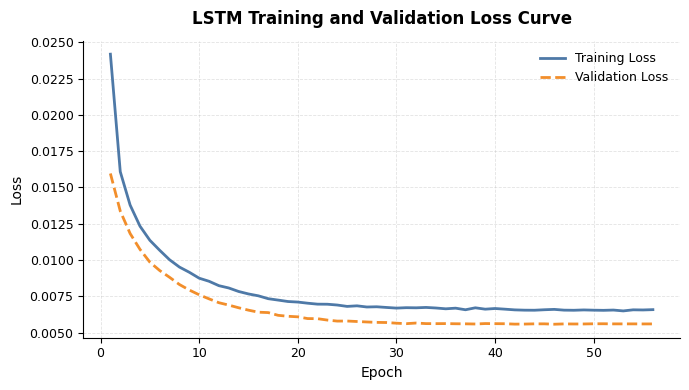

Saved: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\figures\notebook11\fig_lstm_training_validation_loss.png


In [149]:
from src.utils.plotting import STYLE, plot_loss_curve

lstm_result_dir = first_existing_path([
    RESULTS_ROOT / "exp06_lstm_daily",
])

if lstm_result_dir is None:
    raise FileNotFoundError("Could not find the LSTM result directory.")

lstm_history_path = lstm_result_dir / "training_history.json"
lstm_history = load_json_if_exists(lstm_history_path)

if lstm_history is None:
    raise FileNotFoundError(f"Missing LSTM training history: {lstm_history_path}")

# smaller report-ready size
old_figsize = STYLE.figsize
STYLE.figsize = (7.0, 4.0)

lstm_loss_path = FIGURES_DIR / "fig_lstm_training_validation_loss.png"

plot_loss_curve(
    history=lstm_history,
    title="LSTM Training and Validation Loss Curve",
    save_path=str(lstm_loss_path),
    train_key="loss",
    val_key="val_loss",
    train_label="Training Loss",
    val_label="Validation Loss",
    show=True,
)

STYLE.figsize = old_figsize

print("Saved:", lstm_loss_path)

In [150]:
history_df = pd.DataFrame({
    "epoch": np.arange(1, len(lstm_history["loss"]) + 1),
    "loss": lstm_history["loss"],
    "val_loss": lstm_history.get("val_loss", [np.nan] * len(lstm_history["loss"]))
})

display(history_df.head())
display(history_df.tail())

,epoch,loss,val_loss
0,1,0.024177,0.015960
1,2,0.016082,0.013371
2,3,0.013783,0.011825
3,4,0.012332,0.010735
4,5,0.011360,0.009854


,epoch,loss,val_loss
51,52,0.006555,0.005603
52,53,0.006496,0.005603
53,54,0.006571,0.005603
54,55,0.006562,0.005599
55,56,0.006583,0.005601


In [151]:
excel_path = EXPORTS_DIR / "notebook11_report_ready_tables.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    if "results_df" in globals():
        results_df.to_excel(writer, sheet_name="master_results", index=False)
    if "strategy_table" in globals():
        strategy_table.to_excel(writer, sheet_name="strategy_table", index=False)
    if "ranking_table" in globals():
        ranking_table.to_excel(writer, sheet_name="ranking_table", index=False)
    if "selection_table" in globals():
        selection_table.to_excel(writer, sheet_name="selection_table", index=False)

    train_pred_table.to_excel(writer, sheet_name="table_5a_train_pred", index=False)
    test_pred_table.to_excel(writer, sheet_name="table_5b_test_pred", index=False)
    prediction_metrics_df.to_excel(writer, sheet_name="pred_metrics_combined", index=False)

print("Saved:", excel_path)

ModuleNotFoundError: No module named 'openpyxl'